In [ ]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import shap
import sys
import numpy as np
sys.path.append('./src/')

import torch
from data_utils import get_dataframe, drop_future, add_weekend_cond, add_holidays_cond
from train_utils import get_best_XG_model
from train_utils import get_best_NP_model

DATABASE_URL = '...'

In [ ]:
data_set = "M4"
XG_model_name = "VP-M4-kalvin-kelenfold-ST-XG-final"
NP_model_name = "VP-M4-kalvin-kelenfold-ST-NP-final"

In [ ]:
df_m4 = get_dataframe(data_set)

## raw data

In [ ]:
data = add_weekend_cond(add_holidays_cond(df_m4))

### hour

In [ ]:
data_hour = data.groupby(["is_weekend", 'hour'])["y"].mean()
data_hour_weekend = data_hour.xs(True)
data_hour_weekday = data_hour.xs(False)

### weekday

In [ ]:
data_week = data.groupby(["is_edu_holiday", 'dayofweek'])["y"].mean()
data_week_edu_holiday = data_week.xs(1)
data_week_is_education = data_week.xs(0)

## XG

In [ ]:
model, y_pred, metrics, X_test, y_test, feature_names = get_best_XG_model(df_m4, XG_model_name, DATABASE_URL)

In [ ]:
# Choose output 0
estimator_0 = model.estimators_[1]

# Use TreeExplainer (old API)
explainer = shap.Explainer(estimator_0, feature_names=feature_names)
shap_values = explainer(X_test)

X_test = pd.DataFrame(X_test, columns=feature_names)

shap_values = pd.DataFrame(shap_values.values, columns=feature_names)

X_test = X_test.add_suffix('_data')
shap_values = shap_values.add_suffix('_shap')
concat = pd.concat([X_test, shap_values], axis=1)

In [ ]:
concat["hour_data"] = (concat["hour_data"] + 1) % 24 # moving the hour by one hour since it is the prediction of the next hour

### hour

In [ ]:
xg_boost_hour = concat.groupby(["is_weekend_data", "hour_data"])["hour_shap"].mean()

xg_boost_hour_weekend = xg_boost_hour.xs(True)
xg_boost_hour_weekday = xg_boost_hour.xs(False)

### weekday

In [ ]:
xg_boost_week=concat.groupby(["is_edu_holiday_data","dayofweek_data"])["dayofweek_shap"].mean()
xg_boost_week_edu_holiday=xg_boost_week.xs(1)
xg_boost_week_is_education=xg_boost_week.xs(0)

## NP

In [ ]:
m, forecast, metrics = get_best_NP_model(df_m4, NP_model_name, DATABASE_URL)

In [ ]:
def fourier_series_numpy_numeric(t, period, series_order):
    features = np.column_stack(
        [fun((2.0 * (i + 1) * np.pi * t / period)) for i in range(series_order) for fun in (np.sin, np.cos)]
    )
    return features

def compute_seasonality_fourier(m, name="weekly_edu_holiday", n_steps=1000):
    """
    Computes the Fourier-based seasonality prediction for a given seasonality name.

    Args:
        m: A model object with attributes `config_seasonality.periods` and `model.seasonality.compute_fourier`.
        name (str): The seasonality name to compute.
        n_steps (int): Number of time steps.

    Returns:
        np.ndarray: Predicted seasonality values.
    """
    config = m.config_seasonality.periods[name]
    t_i = np.arange(n_steps + 1) / float(n_steps) * config.period
    
    features = fourier_series_numpy_numeric(t=t_i, period=config.period, series_order=config.resolution)
    features = torch.from_numpy(np.expand_dims(features, 1).astype(np.float32))

    predicted = m.model.seasonality.compute_fourier(features=features, name=name)
    predicted = predicted.squeeze().detach().numpy()
    if "weekly" in name:
        shift_points = (len(predicted) // 2) #+ (len(predicted)//(7*2))
        predicted = np.concatenate((predicted[shift_points:], predicted[:shift_points]))
    return predicted

In [ ]:
weekly_edu_holiday = compute_seasonality_fourier(m, "weekly_edu_holiday", 1000)
weekly_education = compute_seasonality_fourier(m, "weekly_education", 1000)
daily_weekday = compute_seasonality_fourier(m, "daily_weekday", 1000)
daily_weekend = compute_seasonality_fourier(m, "daily_weekend", 1000)

## Plot them together

#### hour

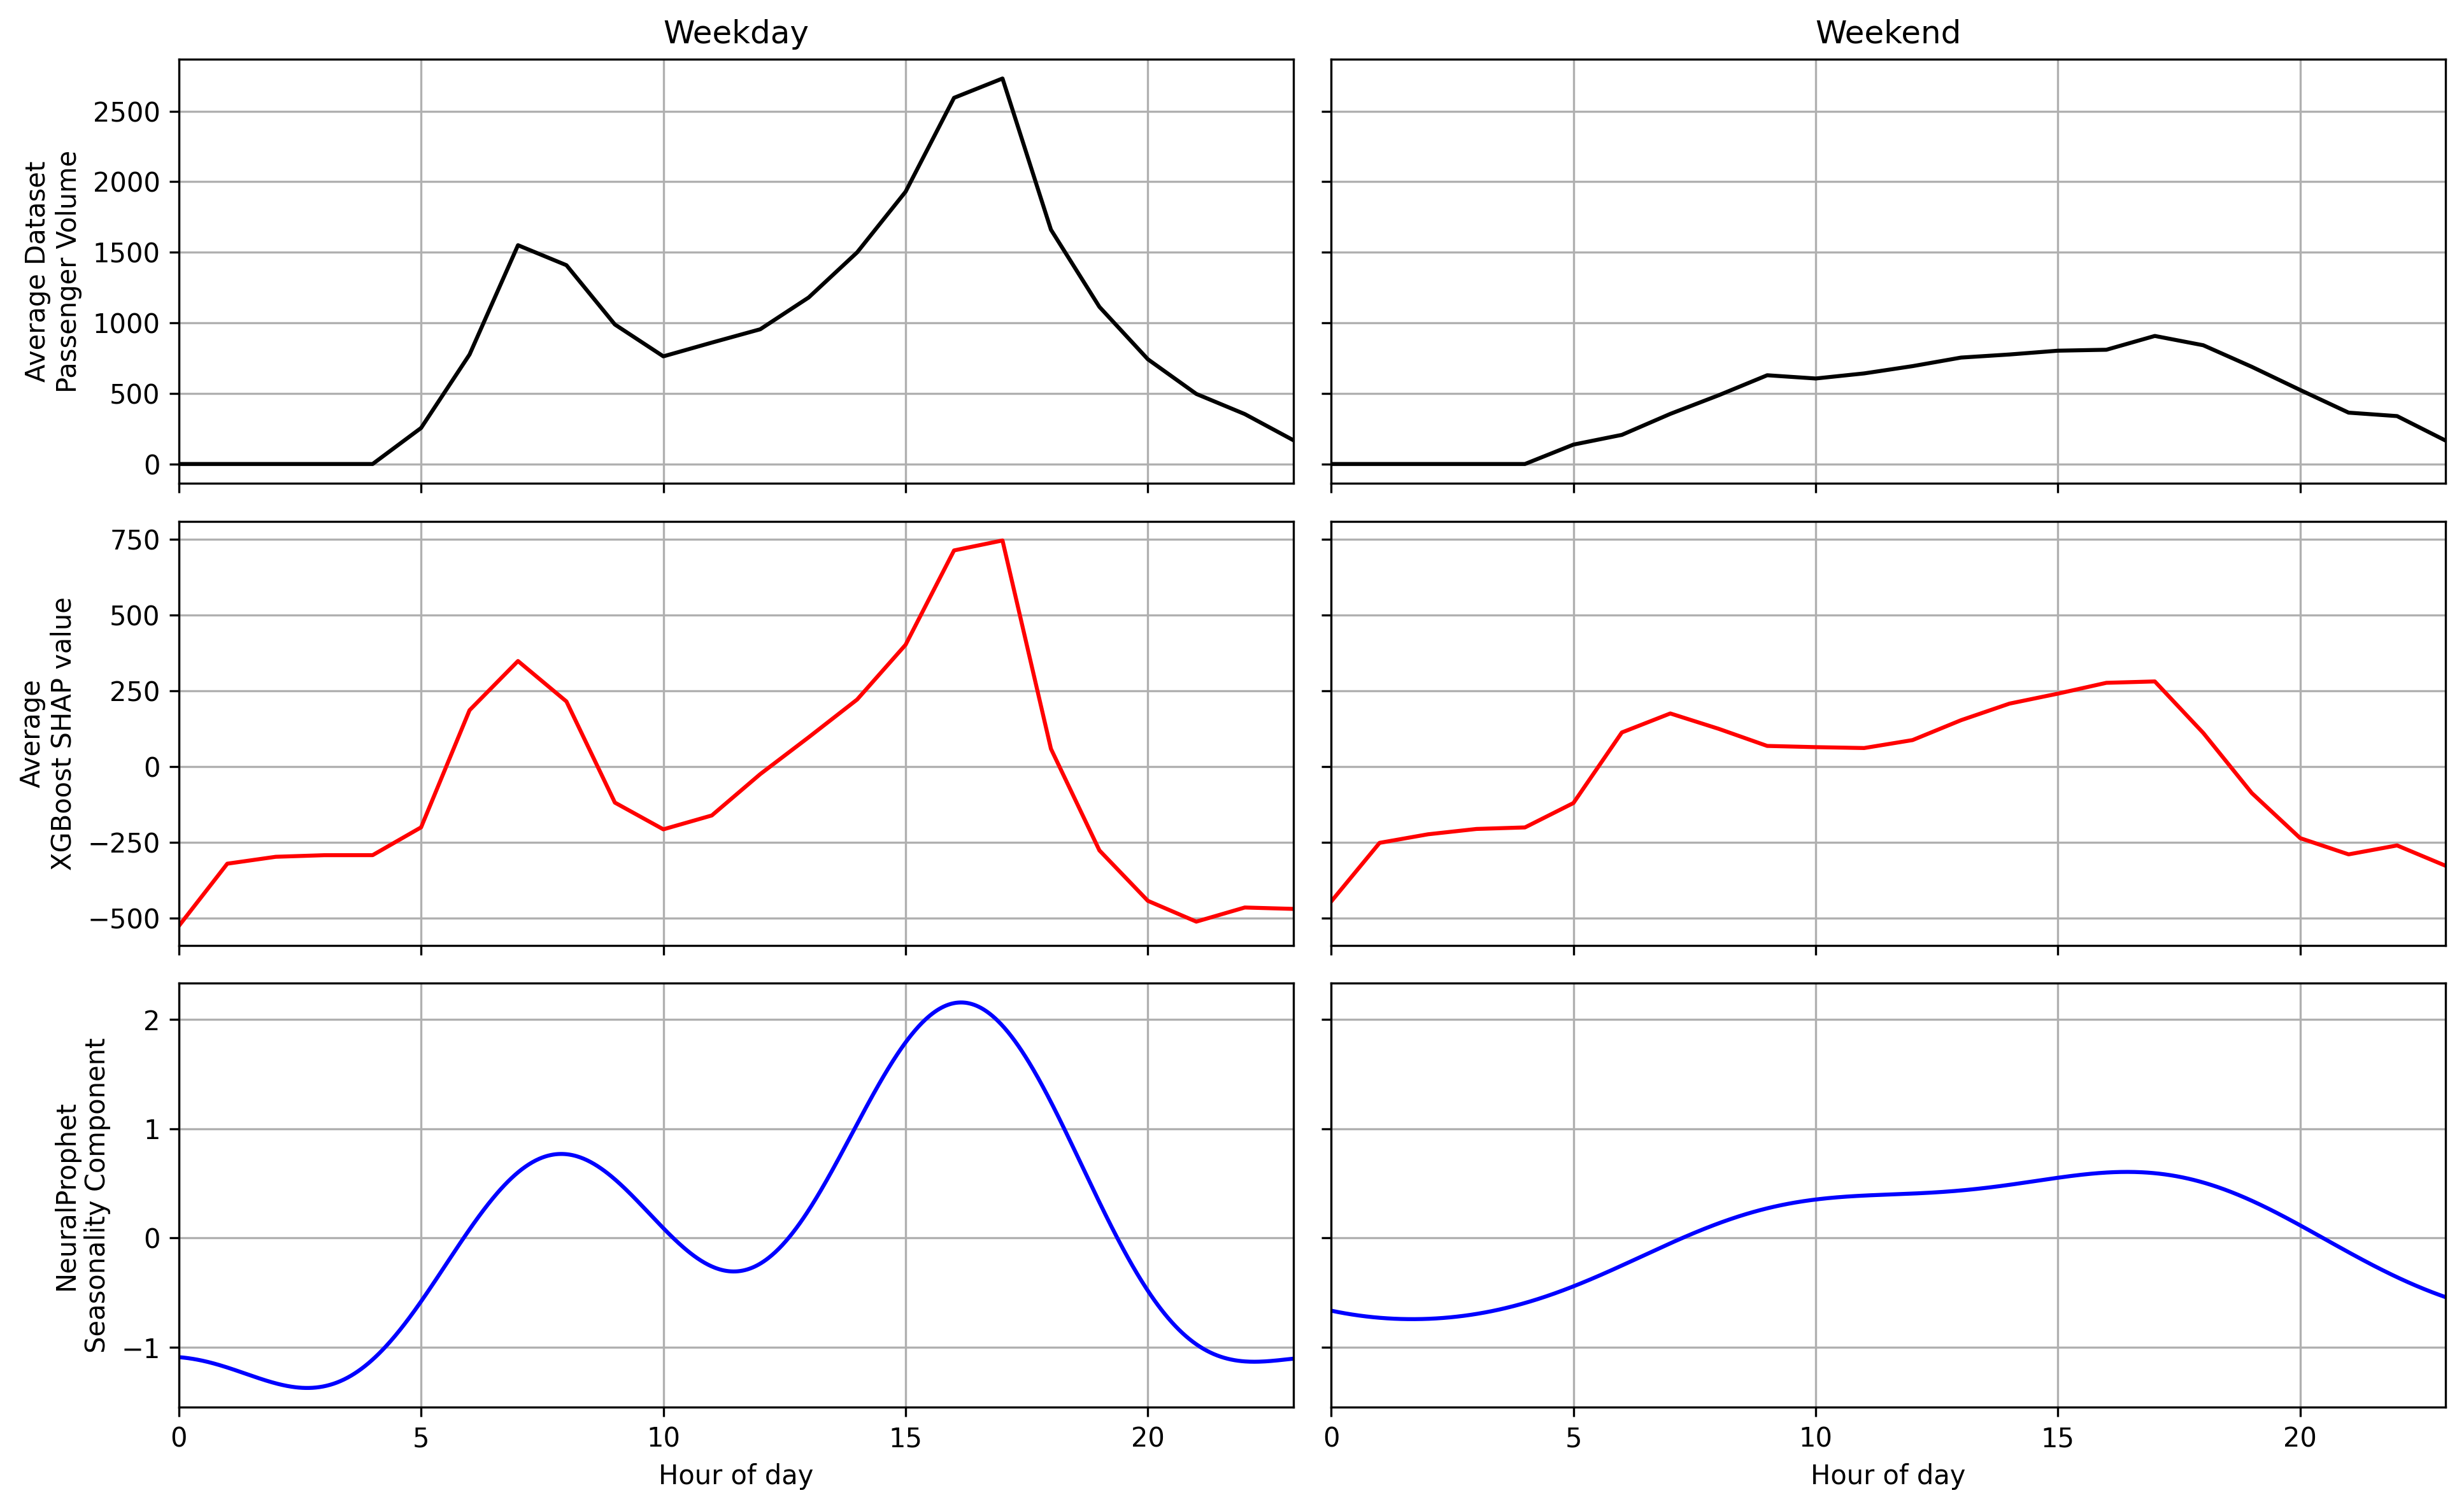

In [50]:
fig, axes = plt.subplots(3, 2, figsize=(13, 8), sharey='row', sharex='col',  dpi=300)

x_24 = np.arange(24)

# 1st row
axes[0][0].plot(x_24, data_hour_weekday, label='data_hour_weekday', color='black')
axes[0][0].set_ylabel("Average Dataset\nPassenger Volume")
axes[0][0].set_title("Weekday")
axes[0][0].grid(True)

axes[0][1].plot(x_24, data_hour_weekend, label='data_hour_weekend', color='black')
axes[0][1].set_title("Weekend")
axes[0][1].grid(True)

# 2nd row
axes[1][0].plot(x_24, xg_boost_hour_weekday, label='xg_boost_hour_weekday', color='red')
axes[1][0].set_ylabel("Average\nXGBoost SHAP value")
axes[1][0].grid(True)

axes[1][1].plot(x_24, xg_boost_hour_weekend, label='xg_boost_hour_weekend', color='red')
axes[1][1].grid(True)

# 3rd row
x_1000 = np.linspace(0, 24, len(daily_weekday))
axes[2][0].plot(x_1000, daily_weekday, label='daily_weekday', color='blue')
axes[2][0].set_xlabel("Hour of day")
axes[2][0].set_xlim(0,23)
axes[2][0].set_ylabel("NeuralProphet\nSeasonality Component")
axes[2][0].grid(True)

axes[2][1].plot(x_1000, daily_weekend, label='daily_weekend', color='blue')
axes[2][1].set_xlabel("Hour of day")
axes[2][1].set_xlim(0,23)
axes[2][1].grid(True)

plt.tight_layout()
plt.show()